# Part-of-Speech Tagging using Hidden Markov Models

**Course:** Natural Language Processing S2-25_AIMLCZG530  
**Assignment:** HMM based POS tagging from scratch  
**Dataset:** NLTK Brown corpus, training category `news`, testing category `fiction`  
**Group:** 108

## Team Members

| Name | BITS ID |
|---|---|
| ARTHIKA G | 2025ab05180 |
| SRINEVEDA R S | 2025ab05206 |
| ASWATHY H | 2025ab05203 |
| PRASHANT | 2025ab05113 |
| SUKANYA YADAV | 2025aa05630 |


## Objective and Marks Coverage

This notebook implements a Bigram Hidden Markov Model (HMM) for POS tagging from scratch, estimates transition and emission probabilities using maximum likelihood estimation with smoothing, decodes sequences using a hand-written Viterbi algorithm, and compares the model with a pre-trained POS tagger.

Coverage map:

- Part 1: Data loading, EDA, vocabulary/OOV handling, sentence padding, and full-fiction test setup.
- Part 2: Explicit transition matrix, emission matrix, OOV mechanism, and Viterbi decoder from scratch.
- Part 3: Inference on 2 training and 2 test sentences, 3 error-analysis examples, token accuracy, and top-5 POS confusion matrix.
- Part D: Pre-trained baseline comparison and discussion.


In [22]:
import math
import random
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from nltk.corpus import brown

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

def ensure_nltk_resource(resource_path, package_name):
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(package_name, quiet=True)

ensure_nltk_resource("corpora/brown", "brown")
ensure_nltk_resource("taggers/universal_tagset", "universal_tagset")

# NLTK changed the perceptron tagger resource name across versions.
for package_name in ["averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"]:
    try:
        nltk.download(package_name, quiet=True)
    except Exception:
        pass

print("Environment ready. Output directory:", OUTPUT_DIR)


Environment ready. Output directory: c:\Users\aganesan2\Downloads\watermark\SEM_2_Assignments\NLP_ASSIGNMENT_1\outputs


## Part 1: Data Preprocessing and EDA

The Brown corpus is loaded with `news` as the training category and `fiction` as the test category, as required. The universal POS tagset is used to reduce sparsity and make the model/evaluation easier to interpret.


In [23]:
TRAIN_CATEGORY = "news"
TEST_CATEGORY = "fiction"

def to_plain_sentences(tagged_sents):
    return [[(str(word), str(tag)) for word, tag in sentence] for sentence in tagged_sents]

raw_train_sents = to_plain_sentences(brown.tagged_sents(categories=TRAIN_CATEGORY, tagset="universal"))
raw_fiction_sents = to_plain_sentences(brown.tagged_sents(categories=TEST_CATEGORY, tagset="universal"))

train_tokens = [(word, tag) for sentence in raw_train_sents for word, tag in sentence]
fiction_tokens = [(word, tag) for sentence in raw_fiction_sents for word, tag in sentence]

print(f"Training category: {TRAIN_CATEGORY}")
print(f"Testing category: {TEST_CATEGORY}")
print(f"Training sentences: {len(raw_train_sents):,}")
print(f"Fiction/test sentences: {len(raw_fiction_sents):,}")
print(f"Training tokens: {len(train_tokens):,}")
print(f"Fiction/test tokens: {len(fiction_tokens):,}")
print("Sample training sentence:")
print(raw_train_sents[0])


Training category: news
Testing category: fiction
Training sentences: 4,623
Fiction/test sentences: 4,249
Training tokens: 100,554
Fiction/test tokens: 68,488
Sample training sentence:
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


,Metric,Value
0,Training sentences,4623
1,Fiction sentences,4249
2,Training tokens,100554
3,Fiction tokens,68488
4,Training vocabulary size,13112
5,Number of POS tags,12


Most common training words:


,Word,Frequency
0,the,6386
1,",",5188
2,.,4030
3,of,2861
4,and,2186
5,to,2144
6,a,2130
7,in,2020
8,for,969
9,that,829


POS tag counts in training data:


,POS Tag,Frequency
0,NOUN,30654
1,VERB,14399
2,ADP,12355
3,.,11928
4,DET,11389
5,ADJ,6706
6,ADV,3349
7,CONJ,2717
8,PRON,2535
9,PRT,2264


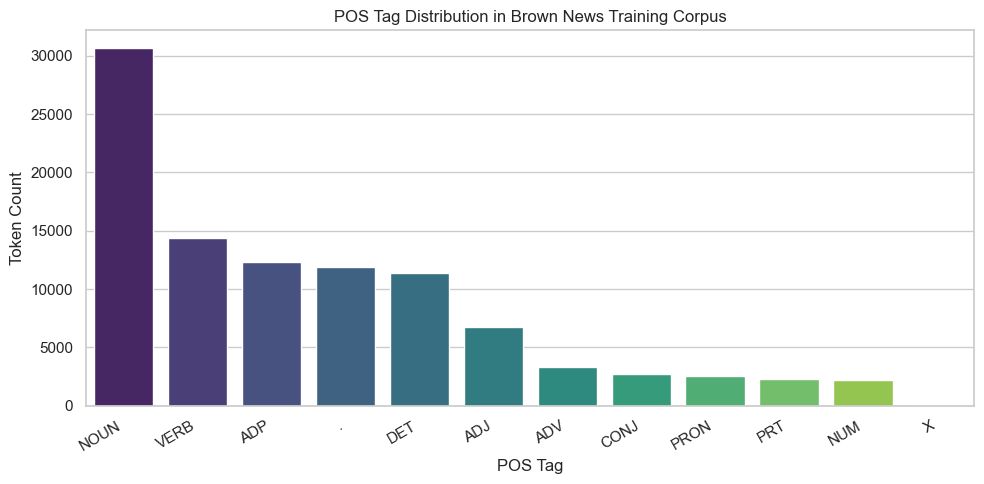

In [24]:
train_word_counts_raw = Counter(word.lower() for word, _ in train_tokens)
train_tag_counts = Counter(tag for _, tag in train_tokens)
fiction_tag_counts = Counter(tag for _, tag in fiction_tokens)

eda_summary = pd.DataFrame(
    [
        ["Training sentences", len(raw_train_sents)],
        ["Fiction sentences", len(raw_fiction_sents)],
        ["Training tokens", len(train_tokens)],
        ["Fiction tokens", len(fiction_tokens)],
        ["Training vocabulary size", len(train_word_counts_raw)],
        ["Number of POS tags", len(train_tag_counts)],
    ],
    columns=["Metric", "Value"],
)
display(eda_summary)

print("Most common training words:")
display(pd.DataFrame(train_word_counts_raw.most_common(15), columns=["Word", "Frequency"]))

print("POS tag counts in training data:")
tag_distribution_df = pd.DataFrame(train_tag_counts.most_common(), columns=["POS Tag", "Frequency"])
display(tag_distribution_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=tag_distribution_df, x="POS Tag", y="Frequency", palette="viridis")
plt.title("POS Tag Distribution in Brown News Training Corpus")
plt.xlabel("POS Tag")
plt.ylabel("Token Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pos_tag_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


### Vocabulary Handling and Unknown Words

The HMM can only emit words observed in training. To reduce failures on out-of-vocabulary words, rare training words are replaced with interpretable unknown-word classes. Test words that were not learned from training are mapped to the same classes.

Unknown classes used here include numeric tokens, capitalized words, hyphenated words, and common suffix patterns such as `-ing`, `-ed`, `-ly`, noun-like suffixes, and adjective-like suffixes.


In [25]:
RARE_WORD_THRESHOLD = 1

UNKNOWN_CLASSES = [
    "<UNK>",
    "<UNK_NUM>",
    "<UNK_CAP>",
    "<UNK_HYPHEN>",
    "<UNK_ING>",
    "<UNK_ED>",
    "<UNK_LY>",
    "<UNK_NOUN_SUFFIX>",
    "<UNK_ADJ_SUFFIX>",
]

def normalize_known_word(word):
    return word.lower()

def unknown_signature(word):
    lower = word.lower()
    if any(char.isdigit() for char in word):
        return "<UNK_NUM>"
    if "-" in word:
        return "<UNK_HYPHEN>"
    if word[:1].isupper():
        return "<UNK_CAP>"
    if lower.endswith("ing"):
        return "<UNK_ING>"
    if lower.endswith("ed"):
        return "<UNK_ED>"
    if lower.endswith("ly"):
        return "<UNK_LY>"
    if lower.endswith(("tion", "ment", "ness", "ity", "ship")):
        return "<UNK_NOUN_SUFFIX>"
    if lower.endswith(("ous", "ful", "able", "ible", "ive", "al")):
        return "<UNK_ADJ_SUFFIX>"
    return "<UNK>"

train_word_counts = Counter(normalize_known_word(word) for word, _ in train_tokens)

def map_word_for_training(word):
    normalized = normalize_known_word(word)
    if train_word_counts[normalized] <= RARE_WORD_THRESHOLD:
        return unknown_signature(word)
    return normalized

processed_train_sents = [
    [(map_word_for_training(word), tag) for word, tag in sentence]
    for sentence in raw_train_sents
]

learned_vocabulary = sorted({word for sentence in processed_train_sents for word, _ in sentence} | set(UNKNOWN_CLASSES))
word_to_index = {word: index for index, word in enumerate(learned_vocabulary)}
index_to_word = {index: word for word, index in word_to_index.items()}

known_normalized_words = {word for word, count in train_word_counts.items() if count > RARE_WORD_THRESHOLD}

def map_word_for_inference(word):
    normalized = normalize_known_word(word)
    if normalized in known_normalized_words:
        return normalized
    signature = unknown_signature(word)
    if signature in word_to_index:
        return signature
    return "<UNK>"

oov_summary = pd.DataFrame(
    [
        ["Rare threshold", RARE_WORD_THRESHOLD],
        ["Raw training vocabulary", len(train_word_counts)],
        ["Model vocabulary after rare-word mapping", len(learned_vocabulary)],
        ["Unknown classes", len(UNKNOWN_CLASSES)],
    ],
    columns=["Metric", "Value"],
)
display(oov_summary)

rare_examples = [(word, train_word_counts[word], unknown_signature(word)) for word in list(train_word_counts.keys())[:200] if train_word_counts[word] <= RARE_WORD_THRESHOLD]
display(pd.DataFrame(rare_examples[:12], columns=["Rare word", "Training count", "Mapped unknown class"]))


,Metric,Value
0,Rare threshold,1
1,Raw training vocabulary,13112
2,Model vocabulary after rare-word mapping,6287
3,Unknown classes,9


,Rare word,Training count,Mapped unknown class
0,term-end,1,<UNK_HYPHEN>
1,presentments,1,<UNK>
2,september-october,1,<UNK_HYPHEN>
3,durwood,1,<UNK>
4,pye,1,<UNK>
5,hard-fought,1,<UNK_HYPHEN>
6,mayor-nominate,1,<UNK_HYPHEN>
7,handful,1,<UNK_ADJ_SUFFIX>
8,outmoded,1,<UNK_ED>
9,ambiguous,1,<UNK_ADJ_SUFFIX>


### Sentence Padding and Test Setup

Sentence boundaries are represented through special POS states `<START>` and `<END>`. This allows the transition matrix to learn which tags commonly start and end a sentence.

The assignment specifies `news` for training and `fiction` for testing. Following the Dataset specification, this notebook trains on all `news` sentences and evaluates on the entire `fiction` corpus as the final test set.


In [26]:
START_TAG = "<START>"
END_TAG = "<END>"

def padded_tags(sentence):
    return [START_TAG] + [tag for _, tag in sentence] + [END_TAG]

heldout_test_sents = raw_fiction_sents

split_summary = pd.DataFrame(
    [
        ["HMM training category", TRAIN_CATEGORY],
        ["HMM training sentences", len(raw_train_sents)],
        ["External test category", TEST_CATEGORY],
        ["Final fiction test sentences", len(heldout_test_sents)],
    ],
    columns=["Item", "Value"],
)
display(split_summary)

print("Example padded tag sequence:")
print(padded_tags(raw_train_sents[0]))

,Item,Value
0,HMM training category,news
1,HMM training sentences,4623
2,External test category,fiction
3,Final fiction test sentences,4249


Example padded tag sequence:
['<START>', 'DET', 'NOUN', 'NOUN', 'ADJ', 'NOUN', 'VERB', 'NOUN', 'DET', 'NOUN', 'ADP', 'NOUN', 'ADJ', 'NOUN', 'NOUN', 'VERB', '.', 'DET', 'NOUN', '.', 'ADP', 'DET', 'NOUN', 'VERB', 'NOUN', '.', '<END>']


## Part 2: Bigram HMM Architecture and Parameter Estimation

A Bigram HMM has:

- Hidden states: POS tags.
- Observations: words.
- Transition probability: `P(tag_i | tag_{i-1})`.
- Emission probability: `P(word_i | tag_i)`.

Both matrices are estimated explicitly from training counts using maximum likelihood estimation with additive smoothing.


In [27]:
TRANSITION_ALPHA = 1e-6
EMISSION_ALPHA = 1e-6

state_tags = sorted({tag for sentence in processed_train_sents for _, tag in sentence})
from_tags = [START_TAG] + state_tags
to_tags = state_tags + [END_TAG]

from_tag_to_index = {tag: index for index, tag in enumerate(from_tags)}
to_tag_to_index = {tag: index for index, tag in enumerate(to_tags)}
state_to_index = {tag: index for index, tag in enumerate(state_tags)}

transition_counts = np.zeros((len(from_tags), len(to_tags)), dtype=np.float64)
tag_bigram_counts = Counter()

for sentence in processed_train_sents:
    tag_sequence = padded_tags(sentence)
    for previous_tag, current_tag in zip(tag_sequence[:-1], tag_sequence[1:]):
        transition_counts[from_tag_to_index[previous_tag], to_tag_to_index[current_tag]] += 1
        tag_bigram_counts[(previous_tag, current_tag)] += 1

transition_denominators = transition_counts.sum(axis=1, keepdims=True) + TRANSITION_ALPHA * len(to_tags)
transition_probs = (transition_counts + TRANSITION_ALPHA) / transition_denominators
transition_log_probs = np.log(transition_probs)

emission_counts = np.zeros((len(state_tags), len(learned_vocabulary)), dtype=np.float64)
emission_pair_counts = Counter()
tag_token_counts = Counter()

for sentence in processed_train_sents:
    for word, tag in sentence:
        emission_counts[state_to_index[tag], word_to_index[word]] += 1
        emission_pair_counts[(tag, word)] += 1
        tag_token_counts[tag] += 1

emission_denominators = emission_counts.sum(axis=1, keepdims=True) + EMISSION_ALPHA * len(learned_vocabulary)
emission_probs = (emission_counts + EMISSION_ALPHA) / emission_denominators
emission_log_probs = np.log(emission_probs)

transition_df = pd.DataFrame(transition_probs, index=from_tags, columns=to_tags)
emission_df = pd.DataFrame(emission_probs, index=state_tags, columns=learned_vocabulary)

parameter_summary = pd.DataFrame(
    [
        ["Number of hidden POS states", len(state_tags)],
        ["Vocabulary size used by emissions", len(learned_vocabulary)],
        ["Transition matrix shape", str(transition_probs.shape)],
        ["Emission matrix shape", str(emission_probs.shape)],
        ["Transition smoothing alpha", TRANSITION_ALPHA],
        ["Emission smoothing alpha", EMISSION_ALPHA],
    ],
    columns=["Parameter", "Value"],
)
display(parameter_summary)


,Parameter,Value
0,Number of hidden POS states,12
1,Vocabulary size used by emissions,6287
2,Transition matrix shape,"(13, 13)"
3,Emission matrix shape,"(12, 6287)"
4,Transition smoothing alpha,0.000001
5,Emission smoothing alpha,0.000001


Transition probability matrix snapshot:


,NOUN,VERB,ADP,.,DET,ADJ,ADV,CONJ,<END>
<START>,0.2613,0.0368,0.0986,0.0876,0.2414,0.0450,0.0543,0.0363,0.0000
NOUN,0.2582,0.1366,0.2120,0.2511,0.0122,0.0169,0.0204,0.0475,0.0055
VERB,0.1267,0.2022,0.1736,0.0645,0.1790,0.0510,0.0731,0.0097,0.0038
ADP,0.3060,0.0378,0.0168,0.0086,0.4402,0.0771,0.0108,0.0011,0.0001
.,0.1393,0.0869,0.0669,0.0815,0.0755,0.0267,0.0324,0.0501,0.3642
DET,0.6473,0.0543,0.0081,0.0104,0.0053,0.2335,0.0132,0.0004,0.0003
ADJ,0.7095,0.0160,0.0728,0.0650,0.0048,0.0610,0.0054,0.0259,0.0019
ADV,0.0543,0.2735,0.1556,0.1329,0.0803,0.1203,0.0755,0.0158,0.0027
CONJ,0.3452,0.1763,0.0574,0.0169,0.1435,0.1078,0.0582,0.0000,0.0000


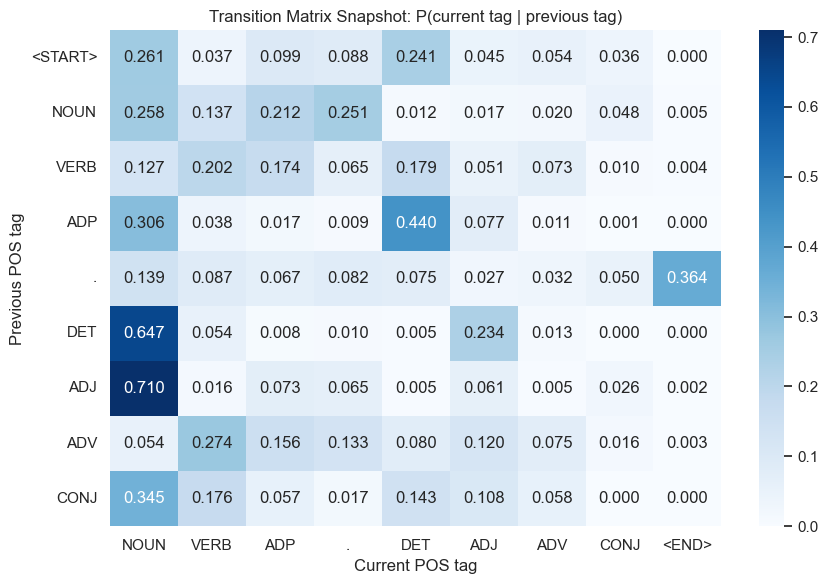

Top emitted words/classes for selected POS tags:


,POS Tag,Word/Class,Emission Probability
0,NOUN,<UNK_CAP>,0.058720
1,NOUN,<UNK>,0.053566
2,NOUN,mrs.,0.008253
3,NOUN,<UNK_HYPHEN>,0.007731
4,NOUN,<UNK_NOUN_SUFFIX>,0.006100
5,NOUN,mr.,0.005546
6,NOUN,<UNK_NUM>,0.005089
7,NOUN,state,0.004926
8,NOUN,year,0.004632
9,NOUN,president,0.004632


,POS Tag,Word/Class,Emission Probability
0,VERB,is,0.050906
1,VERB,was,0.049795
2,VERB,be,0.036530
3,VERB,<UNK_ED>,0.035280
4,VERB,said,0.028196
5,VERB,<UNK>,0.027294
6,VERB,will,0.026946
7,VERB,are,0.022918
8,VERB,<UNK_ING>,0.022502
9,VERB,has,0.020904


,POS Tag,Word/Class,Emission Probability
0,ADJ,<UNK>,0.043394
1,ADJ,new,0.035938
2,ADJ,<UNK_HYPHEN>,0.032210
3,ADJ,last,0.025500
4,ADJ,<UNK_ADJ_SUFFIX>,0.024456
5,ADJ,other,0.024456
6,ADJ,first,0.021026
7,ADJ,more,0.019982
8,ADJ,<UNK_NUM>,0.014614
9,ADJ,national,0.010737


,POS Tag,Word/Class,Emission Probability
0,ADV,not,0.076739
1,ADV,when,0.050463
2,ADV,<UNK_LY>,0.040609
3,ADV,also,0.038519
4,ADV,now,0.025978
5,ADV,as,0.023290
6,ADV,here,0.021499
7,ADV,then,0.021499
8,ADV,about,0.017916
9,ADV,back,0.017617


In [28]:
top_tags = [tag for tag, _ in train_tag_counts.most_common(8)]
transition_snapshot = transition_df.loc[[START_TAG] + top_tags, top_tags + [END_TAG]].round(4)

print("Transition probability matrix snapshot:")
display(transition_snapshot)

plt.figure(figsize=(9, 6))
sns.heatmap(transition_snapshot, annot=True, fmt=".3f", cmap="Blues", cbar=True)
plt.title("Transition Matrix Snapshot: P(current tag | previous tag)")
plt.xlabel("Current POS tag")
plt.ylabel("Previous POS tag")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transition_matrix_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

print("Top emitted words/classes for selected POS tags:")
for tag in [tag for tag in ["NOUN", "VERB", "ADJ", "ADV"] if tag in state_tags]:
    top_emissions = emission_df.loc[tag].sort_values(ascending=False).head(10)
    display(pd.DataFrame({"POS Tag": tag, "Word/Class": top_emissions.index, "Emission Probability": top_emissions.values}))


### Viterbi Decoder From Scratch

The Viterbi algorithm uses dynamic programming to find the most likely POS tag sequence for an observed word sequence. Log probabilities are used to avoid numerical underflow.


In [29]:
tag_row_indices = np.array([from_tag_to_index[tag] for tag in state_tags])
tag_col_indices = np.array([to_tag_to_index[tag] for tag in state_tags])
start_row_index = from_tag_to_index[START_TAG]
end_col_index = to_tag_to_index[END_TAG]

start_to_tag_log_probs = transition_log_probs[start_row_index, tag_col_indices]
tag_to_tag_log_probs = transition_log_probs[np.ix_(tag_row_indices, tag_col_indices)]
tag_to_end_log_probs = transition_log_probs[tag_row_indices, end_col_index]

def sentence_to_observations(words):
    mapped_words = [map_word_for_inference(word) for word in words]
    return [word_to_index.get(word, word_to_index["<UNK>"]) for word in mapped_words], mapped_words

def viterbi_decode(words):
    if not words:
        return []

    observation_indices, _ = sentence_to_observations(words)
    sequence_length = len(observation_indices)
    number_of_states = len(state_tags)

    scores = np.full((sequence_length, number_of_states), -np.inf, dtype=np.float64)
    backpointers = np.zeros((sequence_length, number_of_states), dtype=np.int64)

    first_emissions = emission_log_probs[:, observation_indices[0]]
    scores[0] = start_to_tag_log_probs + first_emissions

    for position in range(1, sequence_length):
        emission_scores = emission_log_probs[:, observation_indices[position]]
        candidate_scores = scores[position - 1][:, None] + tag_to_tag_log_probs
        backpointers[position] = np.argmax(candidate_scores, axis=0)
        scores[position] = np.max(candidate_scores, axis=0) + emission_scores

    final_scores = scores[-1] + tag_to_end_log_probs
    best_last_state = int(np.argmax(final_scores))

    best_path_indices = [best_last_state]
    for position in range(sequence_length - 1, 0, -1):
        best_path_indices.append(int(backpointers[position, best_path_indices[-1]]))
    best_path_indices.reverse()

    return [state_tags[index] for index in best_path_indices]

def prediction_table(sentence):
    words = [word for word, _ in sentence]
    gold_tags = [tag for _, tag in sentence]
    predicted_tags = viterbi_decode(words)
    mapped_words = [map_word_for_inference(word) for word in words]
    return pd.DataFrame(
        {
            "Token": words,
            "Model word/class": mapped_words,
            "Gold POS": gold_tags,
            "HMM Predicted POS": predicted_tags,
            "Correct": [gold == pred for gold, pred in zip(gold_tags, predicted_tags)],
        }
    )

smoke_sentence = [word for word, _ in raw_train_sents[0]]
print("Smoke-test decoded tags for first training sentence:")
print(viterbi_decode(smoke_sentence))


Smoke-test decoded tags for first training sentence:
['DET', 'NOUN', 'NOUN', 'ADJ', 'NOUN', 'VERB', 'NOUN', 'DET', 'NOUN', 'ADP', 'NOUN', 'ADJ', 'NOUN', 'NOUN', 'VERB', '.', 'DET', 'NOUN', '.', 'ADP', 'DET', 'NOUN', 'VERB', 'NOUN', '.']


## Part 3a: Sequence Inference on Four Sentences

The next cell prints predictions for exactly four sentences: two from the training category and two from the final test set.


In [30]:
def pick_non_trivial(sentences, count, min_tokens=5):
    selected = []
    for sentence in sentences:
        if len(sentence) >= min_tokens:
            selected.append(sentence)
            if len(selected) == count:
                break
    return selected

test_examples = pick_non_trivial(heldout_test_sents, count=2)

example_sentences = [
    ("Training sentence 1", raw_train_sents[0]),
    ("Training sentence 2", raw_train_sents[1]),
    ("Test sentence 1", test_examples[0]),
    ("Test sentence 2", test_examples[1]),
]

for label, sentence in example_sentences:
    print("=" * 100)
    print(label)
    print("Sentence:", " ".join(word for word, _ in sentence))
    display(prediction_table(sentence))

Training sentence 1
Sentence: The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .


,Token,Model word/class,Gold POS,HMM Predicted POS,Correct
0,The,the,DET,DET,True
1,Fulton,fulton,NOUN,NOUN,True
2,County,county,NOUN,NOUN,True
3,Grand,grand,ADJ,ADJ,True
4,Jury,jury,NOUN,NOUN,True
5,said,said,VERB,VERB,True
6,Friday,friday,NOUN,NOUN,True
7,an,an,DET,DET,True
8,investigation,investigation,NOUN,NOUN,True
9,of,of,ADP,ADP,True


Training sentence 2
Sentence: The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .


,Token,Model word/class,Gold POS,HMM Predicted POS,Correct
0,The,the,DET,DET,True
1,jury,jury,NOUN,NOUN,True
2,further,further,ADV,ADV,True
3,said,said,VERB,VERB,True
4,in,in,ADP,ADP,True
5,term-end,<UNK_HYPHEN>,NOUN,ADJ,False
6,presentments,<UNK>,NOUN,NOUN,True
7,that,that,ADP,ADP,True
8,the,the,DET,DET,True
9,City,city,NOUN,NOUN,True


Test sentence 1
Sentence: Scotty did not go back to school .


,Token,Model word/class,Gold POS,HMM Predicted POS,Correct
0,Scotty,<UNK_CAP>,NOUN,NOUN,True
1,did,did,VERB,VERB,True
2,not,not,ADV,ADV,True
3,go,go,VERB,VERB,True
4,back,back,ADV,ADV,True
5,to,to,ADP,ADP,True
6,school,school,NOUN,NOUN,True
7,.,.,.,.,True


Test sentence 2
Sentence: His parents talked seriously and lengthily to their own doctor and to a specialist at the University Hospital -- Mr. McKinley was entitled to a discount for members of his family -- and it was decided it would be best for him to take the remainder of the term off , spend a lot of time in bed and , for the rest , do pretty much as he chose -- provided , of course , he chose to do nothing too exciting or too debilitating .


,Token,Model word/class,Gold POS,HMM Predicted POS,Correct
0,His,his,DET,DET,True
1,parents,parents,NOUN,NOUN,True
2,talked,talked,VERB,VERB,True
3,seriously,seriously,ADV,ADV,True
4,and,and,CONJ,CONJ,True
...,...,...,...,...,...
82,exciting,exciting,ADJ,ADJ,True
83,or,or,CONJ,CONJ,True
84,too,too,ADV,ADV,True
85,debilitating,<UNK_ING>,ADJ,VERB,False


## Part 3b: Misclassification Examples and Error Analysis

The next section searches the final test set for three distinct sentences where the HMM misclassified at least one token, then explains likely causes such as OOV handling, lexical ambiguity, and rare transitions.


In [31]:
train_word_tag_counts = defaultdict(Counter)
for word, tag in train_tokens:
    train_word_tag_counts[normalize_known_word(word)][tag] += 1

def explain_token_error(word, gold_tag, predicted_tag, previous_gold_tag):
    normalized = normalize_known_word(word)
    mapped = map_word_for_inference(word)
    reasons = []

    if normalized not in known_normalized_words:
        reasons.append(f"OOV/rare word mapped to {mapped}")

    if len(train_word_tag_counts[normalized]) > 1:
        observed_tags = ", ".join(f"{tag}:{count}" for tag, count in train_word_tag_counts[normalized].most_common())
        reasons.append(f"lexically ambiguous in training ({observed_tags})")

    transition_count = tag_bigram_counts[(previous_gold_tag, gold_tag)]
    if transition_count <= 2:
        reasons.append(f"rare gold transition {previous_gold_tag}->{gold_tag} in news training")

    emission_count = emission_pair_counts[(gold_tag, mapped)]
    if emission_count <= 1:
        reasons.append(f"weak emission evidence for {gold_tag} emitting {mapped}")

    if not reasons:
        reasons.append("fiction-domain context differed from the news-trained HMM assumptions")

    return "; ".join(reasons)

def find_misclassified_examples(sentences, limit=3, min_tokens=5):
    examples = []
    for sentence in sentences:
        if len(sentence) < min_tokens:
            continue
        table = prediction_table(sentence)
        error_rows = []
        gold_tags = table["Gold POS"].tolist()
        for position, row in table.iterrows():
            if row["Gold POS"] != row["HMM Predicted POS"]:
                previous_gold = gold_tags[position - 1] if position > 0 else START_TAG
                error_rows.append(
                    {
                        "Token": row["Token"],
                        "Model word/class": row["Model word/class"],
                        "Gold POS": row["Gold POS"],
                        "Predicted POS": row["HMM Predicted POS"],
                        "Likely reason": explain_token_error(
                            row["Token"], row["Gold POS"], row["HMM Predicted POS"], previous_gold
                        ),
                    }
                )
        if error_rows:
            examples.append((sentence, table, pd.DataFrame(error_rows)))
        if len(examples) == limit:
            break
    return examples

error_examples = find_misclassified_examples(heldout_test_sents, limit=3)

for index, (sentence, full_table, error_table) in enumerate(error_examples, start=1):
    print("=" * 100)
    print(f"Misclassified sentence {index}:")
    print("Sentence:", " ".join(word for word, _ in sentence))
    print("Misclassified tokens and brief analysis:")
    display(error_table)

Misclassified sentence 1:
Sentence: His parents talked seriously and lengthily to their own doctor and to a specialist at the University Hospital -- Mr. McKinley was entitled to a discount for members of his family -- and it was decided it would be best for him to take the remainder of the term off , spend a lot of time in bed and , for the rest , do pretty much as he chose -- provided , of course , he chose to do nothing too exciting or too debilitating .
Misclassified tokens and brief analysis:


,Token,Model word/class,Gold POS,Predicted POS,Likely reason
0,debilitating,<UNK_ING>,ADJ,VERB,OOV/rare word mapped to <UNK_ING>


Misclassified sentence 2:
Sentence: His teacher and his school principal were conferred with and everyone agreed that , if he kept up with a certain amount of work at home , there was little danger of his losing a term .
Misclassified tokens and brief analysis:


,Token,Model word/class,Gold POS,Predicted POS,Likely reason
0,that,that,ADP,PRON,"lexically ambiguous in training (ADP:546, DET:150, PRON:128, ADV:5)"


Misclassified sentence 3:
Sentence: Rachel wore a smart hat and , because she had been warned recently about smoking , puffed at her cigarettes through a long ivory holder stained with lipstick .
Misclassified tokens and brief analysis:


,Token,Model word/class,Gold POS,Predicted POS,Likely reason
0,smart,<UNK>,ADJ,NOUN,OOV/rare word mapped to <UNK>
1,about,about,ADP,ADV,"lexically ambiguous in training (ADP:85, ADV:60, PRT:2)"
2,ivory,ivory,ADJ,NOUN,weak emission evidence for ADJ emitting ivory


## Part 3c: Full Evaluation on the Fiction Test Set

Token-level accuracy is computed over the entire `fiction` test corpus. Sentence padding states are not included in evaluation.

HMM token-level accuracy on full fiction test set: 93.7449%
Correct tokens: 64,204 / 68,488
Top 5 POS tags by frequency in the final test set: ['NOUN', 'VERB', '.', 'DET', 'ADP']
HMM confusion matrix snapshot for top 5 POS tags:


HMM Predicted POS,NOUN,VERB,.,DET,ADP
Gold POS,,,,,
NOUN,12967,310,0,0,0
VERB,610,11503,0,0,8
.,0,0,10170,0,0
DET,3,0,0,7844,62
ADP,27,59,0,6,6799


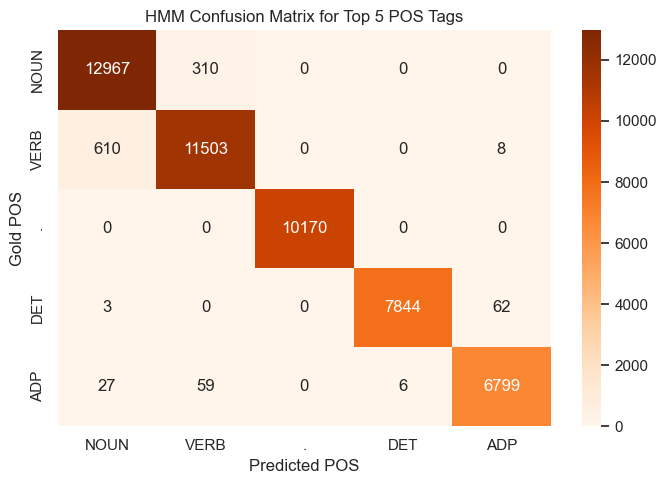

In [32]:
def evaluate_hmm(sentences):
    all_gold = []
    all_predicted = []
    for sentence in sentences:
        words = [word for word, _ in sentence]
        gold_tags = [tag for _, tag in sentence]
        predicted_tags = viterbi_decode(words)
        all_gold.extend(gold_tags)
        all_predicted.extend(predicted_tags)

    correct = sum(gold == pred for gold, pred in zip(all_gold, all_predicted))
    total = len(all_gold)
    accuracy = correct / total if total else 0.0
    return accuracy, correct, total, all_gold, all_predicted

hmm_accuracy, hmm_correct, hmm_total, hmm_gold, hmm_predicted = evaluate_hmm(heldout_test_sents)

print(f"HMM token-level accuracy on full fiction test set: {hmm_accuracy:.4%}")
print(f"Correct tokens: {hmm_correct:,} / {hmm_total:,}")

top5_test_tags = [tag for tag, _ in Counter(hmm_gold).most_common(5)]
hmm_full_confusion = pd.crosstab(
    pd.Series(hmm_gold, name="Gold POS"),
    pd.Series(hmm_predicted, name="HMM Predicted POS"),
    dropna=False,
)
hmm_top5_confusion = hmm_full_confusion.reindex(index=top5_test_tags, columns=top5_test_tags, fill_value=0)

print("Top 5 POS tags by frequency in the final test set:", top5_test_tags)
print("HMM confusion matrix snapshot for top 5 POS tags:")
display(hmm_top5_confusion)

plt.figure(figsize=(7, 5))
sns.heatmap(hmm_top5_confusion, annot=True, fmt="d", cmap="Oranges", cbar=True)
plt.title("HMM Confusion Matrix for Top 5 POS Tags")
plt.xlabel("Predicted POS")
plt.ylabel("Gold POS")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hmm_top5_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


## Part D: Baseline Comparison with a Pre-trained POS Tagger

The baseline uses NLTK's pre-trained averaged perceptron POS tagger. This is not used for the HMM implementation; it is used only for the required comparison section.


,Model,Token Accuracy,Correct Tokens,Total Tokens
0,From-scratch Bigram HMM,93.7449%,64204,68488
1,NLTK pre-trained PerceptronTagger,90.6918%,62113,68488


Baseline confusion matrix snapshot for the same top 5 POS tags:


Baseline Predicted POS,NOUN,VERB,.,DET,ADP
Gold POS,,,,,
NOUN,13014,140,0,1,5
VERB,507,11500,0,0,21
.,0,0,10170,0,0
DET,5,0,0,6261,44
ADP,16,16,0,15,6457


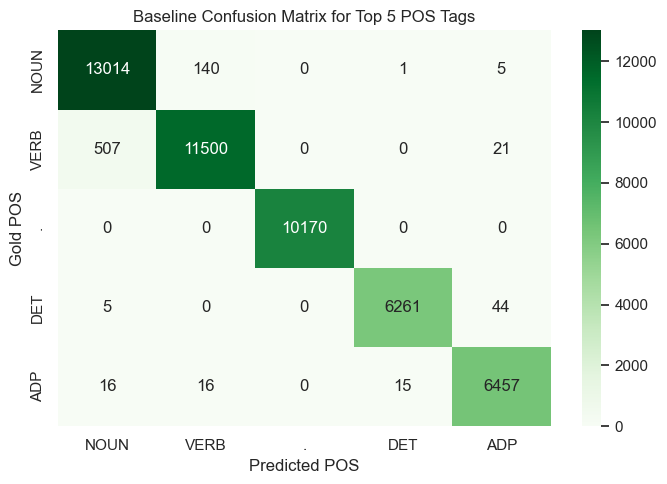

In [33]:
def baseline_pos_tags(words):
    try:
        return [tag for _, tag in nltk.pos_tag(words, tagset="universal")]
    except LookupError:
        for package_name in ["averaged_perceptron_tagger_eng", "averaged_perceptron_tagger", "universal_tagset"]:
            try:
                nltk.download(package_name, quiet=True)
            except Exception:
                pass
        return [tag for _, tag in nltk.pos_tag(words, tagset="universal")]

def evaluate_baseline(sentences):
    all_gold = []
    all_predicted = []
    for sentence in sentences:
        words = [word for word, _ in sentence]
        gold_tags = [tag for _, tag in sentence]
        predicted_tags = baseline_pos_tags(words)
        all_gold.extend(gold_tags)
        all_predicted.extend(predicted_tags)

    correct = sum(gold == pred for gold, pred in zip(all_gold, all_predicted))
    total = len(all_gold)
    accuracy = correct / total if total else 0.0
    return accuracy, correct, total, all_gold, all_predicted

baseline_accuracy, baseline_correct, baseline_total, baseline_gold, baseline_predicted = evaluate_baseline(heldout_test_sents)

comparison_df = pd.DataFrame(
    [
        ["From-scratch Bigram HMM", hmm_accuracy, hmm_correct, hmm_total],
        ["NLTK pre-trained PerceptronTagger", baseline_accuracy, baseline_correct, baseline_total],
    ],
    columns=["Model", "Token Accuracy", "Correct Tokens", "Total Tokens"],
)
comparison_df["Token Accuracy"] = comparison_df["Token Accuracy"].map(lambda value: f"{value:.4%}")
display(comparison_df)

baseline_full_confusion = pd.crosstab(
    pd.Series(baseline_gold, name="Gold POS"),
    pd.Series(baseline_predicted, name="Baseline Predicted POS"),
    dropna=False,
)
baseline_top5_confusion = baseline_full_confusion.reindex(index=top5_test_tags, columns=top5_test_tags, fill_value=0)

print("Baseline confusion matrix snapshot for the same top 5 POS tags:")
display(baseline_top5_confusion)

plt.figure(figsize=(7, 5))
sns.heatmap(baseline_top5_confusion, annot=True, fmt="d", cmap="Greens", cbar=True)
plt.title("Baseline Confusion Matrix for Top 5 POS Tags")
plt.xlabel("Predicted POS")
plt.ylabel("Gold POS")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_top5_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


In [34]:
def find_baseline_rescue_examples(sentences, limit=5):
    rescued_rows = []
    for sentence in sentences:
        words = [word for word, _ in sentence]
        gold_tags = [tag for _, tag in sentence]
        hmm_tags = viterbi_decode(words)
        baseline_tags = baseline_pos_tags(words)
        for word, gold_tag, hmm_tag, baseline_tag in zip(words, gold_tags, hmm_tags, baseline_tags):
            if hmm_tag != gold_tag and baseline_tag == gold_tag:
                rescued_rows.append(
                    {
                        "Token": word,
                        "Gold POS": gold_tag,
                        "HMM POS": hmm_tag,
                        "Baseline POS": baseline_tag,
                        "HMM word/class": map_word_for_inference(word),
                        "Sentence": " ".join(words),
                    }
                )
        if len(rescued_rows) >= limit:
            break
    return pd.DataFrame(rescued_rows[:limit])

rescue_examples = find_baseline_rescue_examples(heldout_test_sents, limit=5)
print("Examples where the baseline is correct and the HMM is wrong:")
display(rescue_examples)


Examples where the baseline is correct and the HMM is wrong:


,Token,Gold POS,HMM POS,Baseline POS,HMM word/class,Sentence
0,debilitating,ADJ,VERB,ADJ,<UNK_ING>,His parents talked seriously and lengthily to their own doctor and to a specialist at the University Hospital -- Mr....
1,that,ADP,PRON,ADP,that,"His teacher and his school principal were conferred with and everyone agreed that , if he kept up with a certain amo..."
2,smart,ADJ,NOUN,ADJ,<UNK>,"Rachel wore a smart hat and , because she had been warned recently about smoking , puffed at her cigarettes through ..."
3,about,ADP,ADV,ADP,about,"Rachel wore a smart hat and , because she had been warned recently about smoking , puffed at her cigarettes through ..."
4,angular,ADJ,NOUN,ADJ,<UNK>,"Scotty's father sat sprawled in his chair , angular , alert as a cricket , looking about at the huge stainless-steel..."


## Discussion: Why the HMM Fails Where the Pre-trained Baseline Often Succeeds

The from-scratch HMM is intentionally simple and interpretable. Its main limitations are:

- It is trained only on Brown `news` but evaluated on Brown `fiction`, so domain shift affects vocabulary, style, and tag transitions.
- It uses a bigram Markov assumption, so the current POS tag depends only on the previous POS tag and not on longer context.
- Emission probabilities are mostly lexical; rare and unseen words must be approximated through unknown-word classes.
- The model cannot directly use rich features such as capitalization patterns, suffixes in combination with context, sentence position, or surrounding words beyond the previous tag.
- Lexically ambiguous words can be difficult because the same surface form may act as a noun, verb, adjective, or adverb depending on context.

The pre-trained perceptron tagger succeeds in many of these cases because it was trained on a larger supervised corpus and uses richer contextual and morphological features. It can learn discriminative cues from neighboring words, capitalization, suffixes, and word-shape patterns rather than relying only on `P(tag_i | tag_{i-1})` and `P(word_i | tag_i)`.


## Virtual Lab code execution Screenshots